In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.size']=30
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

c = 299792
M_B = -19.253

filename = "../data/Pantheon+SH0ES.dat"
data = pd.read_csv(filename, delim_whitespace=True, comment='#')

/var/folders/pl/vxvp849x7cq56cpszbltdh9r0000gn/T/ipykernel_7540/2245686159.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filename, delim_whitespace=True, comment='#')


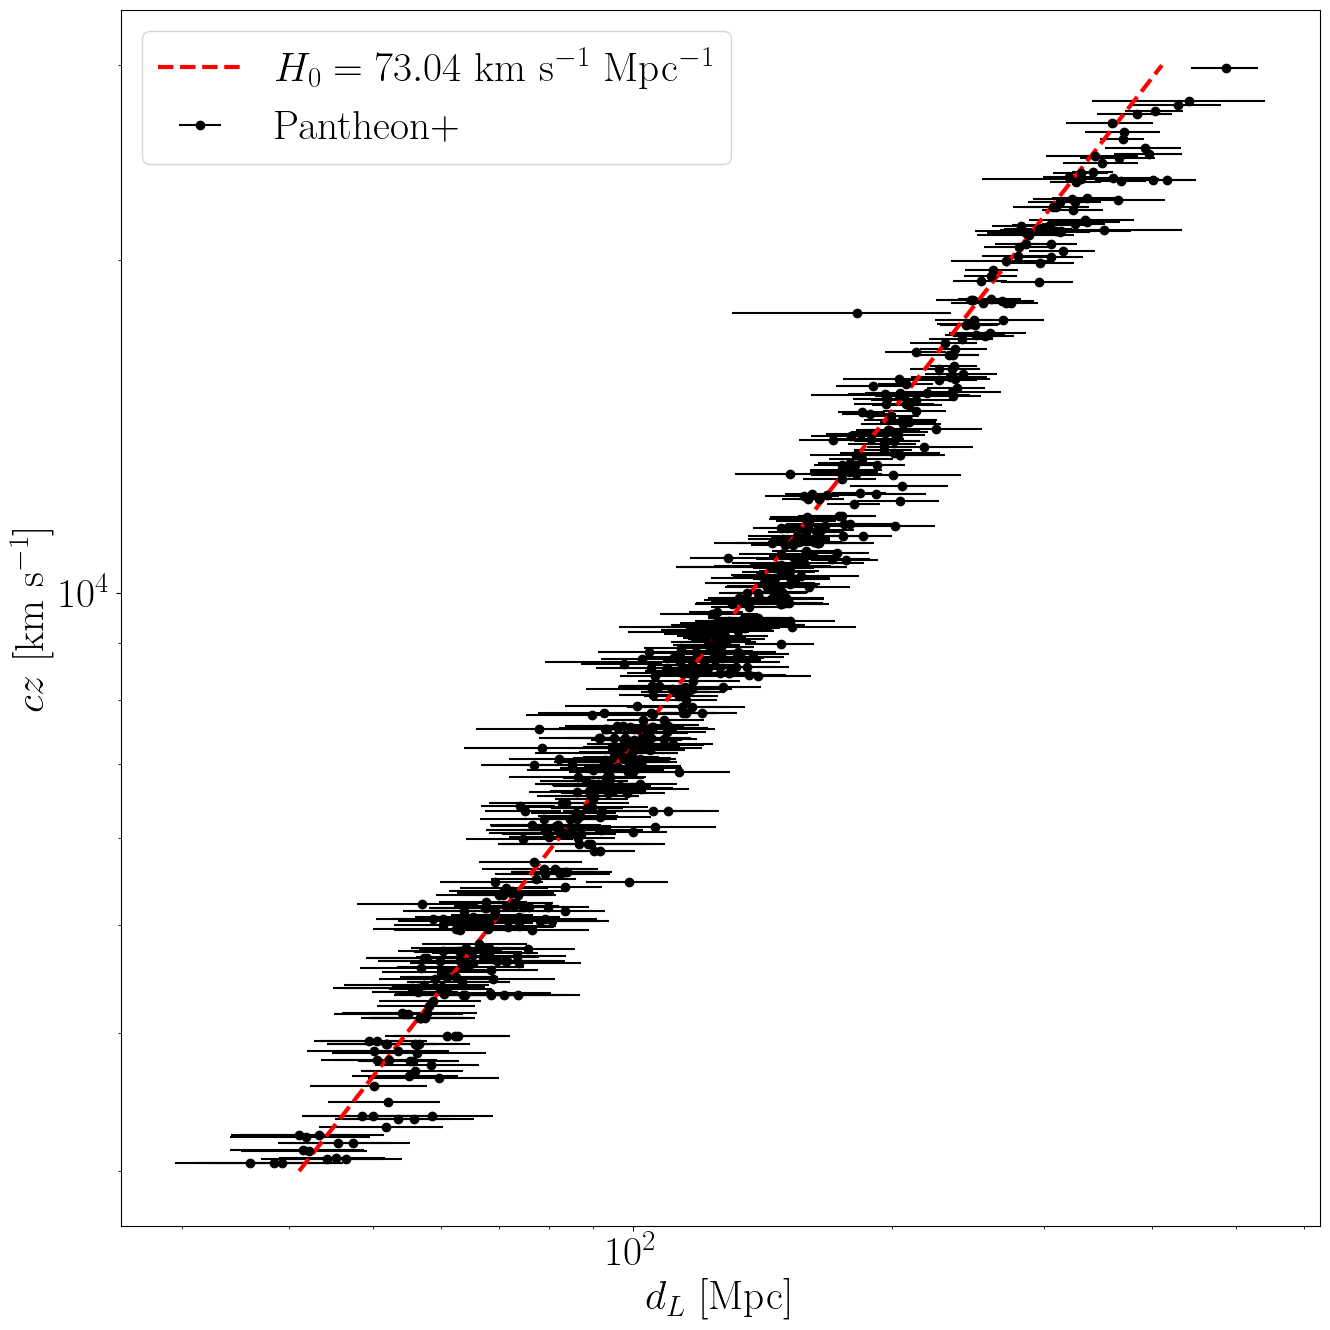

In [3]:
z = data["zHD"].values
mB = data["m_b_corr"].values
sigma_m = data["m_b_corr_err_DIAG"].values

mask = (z > 0.01) & (z < 0.1)
z = z[mask]
mB = mB[mask]
sigma_m = sigma_m[mask]

#this step is computing uncertainty from galaxy motion estimated as ~250 km/s
sigma_mu = (5/np.log(10))*(250.0/(c*z))
sigma_tot = np.sqrt(sigma_m**2 + sigma_mu**2)

d = 10**((mB-M_B+5)/5)/1e6
sigma_d = (np.log(10)/5)*d*sigma_tot

H0 = 73.04

z_plot = np.linspace(0.01, 0.1, 500)
d_plot = c*z_plot/H0

plt.figure(figsize=(14, 14))
plt.errorbar(d, c*z, xerr=sigma_d, fmt='o', color='k', label='Pantheon+')
plt.plot(d_plot, c*z_plot, color='r', linestyle='--', linewidth=3, label=f'$H_0 = {H0:.2f}$ km s$^{{-1}}$ Mpc$^{{-1}}$')
plt.xlabel('$d_L$ [Mpc]')
plt.ylabel('$cz$ [km s$^{-1}$]')
plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.savefig('SN_H_0.jpeg', dpi=300, bbox_inches='tight')
plt.show()